<a href="https://colab.research.google.com/github/jasonhan0916/helloworld/blob/main/461_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASRM 461 F25 Project Simulation and Classification

## Part 1 Convolutions

In this part, you will see the effect of adding two distributions together.

Simulate 10,000 draws from 𝑋𝑋1 and 𝑋𝑋2, then compute their sum 𝑌𝑌 = 𝑋𝑋1 + 𝑋𝑋2.

Plot 𝑋𝑋1, 𝑋𝑋2, and 𝑌𝑌 on histograms. Make a table of values and determine what range of 𝑘𝑘’s have
more than 100 observations.

Classify Y as an (𝑎, 𝑏, 0) distribution and give its parameters by creating a linear regression with
points.You may need to restrict your range to 𝑘𝑘’s with more than 100 observations.

a. 𝑋𝑋1 = Geo(β = 12), 𝑋𝑋2 = Geo(β = 12)

b. 𝑋𝑋1 = Bin(𝑚𝑚 = 24, 𝑞𝑞 = 0.6), 𝑋𝑋2 = Bin(𝑚𝑚 = 36, 𝑞𝑞 = 0.6)

c. 𝑋𝑋1 = Poi(λ = 16), 𝑋𝑋2 = Poi(λ = 20)

In [ ]:
#import useful packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.stats import poisson, expon, binom, gamma, lognorm, norm

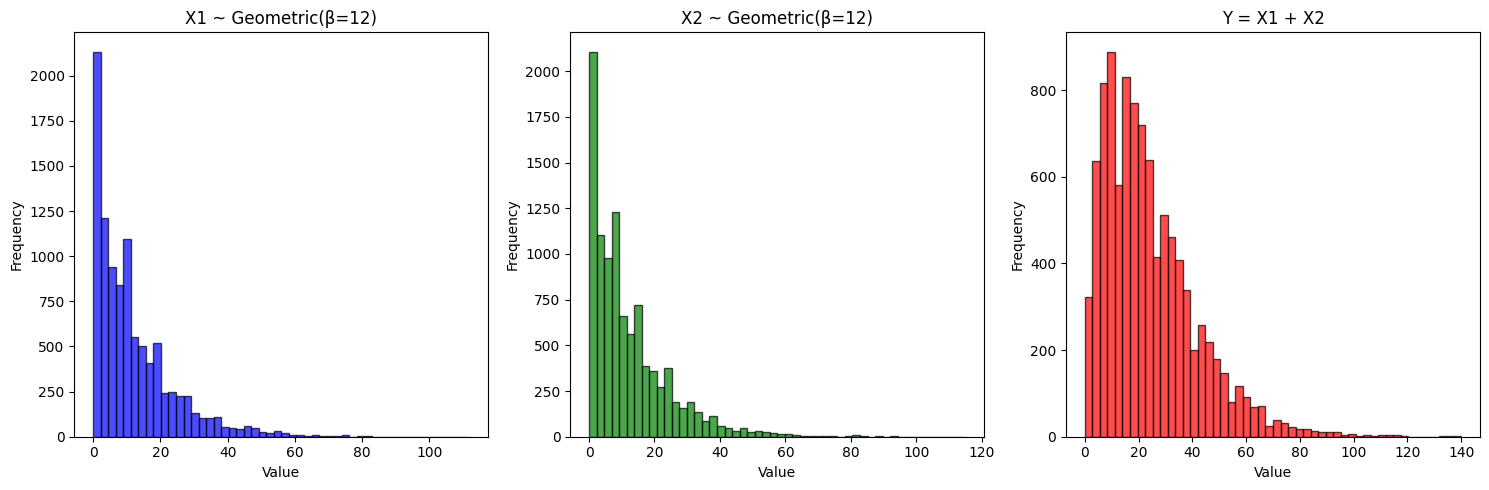

k values with more than 100 observations: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39]
Linear regression results: slope = 0.9788, intercept = 0.2346
a = 0.9788, b = 0.2346
r = 1.2396 , beta = 46.1698


In [ ]:
# a
np.random.seed(1)
n_sim = 10000
X1_a = np.random.geometric(p=1/13, size=n_sim) - 1  # Shift to 0-based
X2_a = np.random.geometric(p=1/13, size=n_sim) - 1
Y_a = X1_a + X2_a

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(X1_a, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title('X1 ~ Geometric(β=12)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(X2_a, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.title('X2 ~ Geometric(β=12)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(Y_a, bins=50, alpha=0.7, color='red', edgecolor='black')
plt.title('Y = X1 + X2')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Create frequency table and find k's with more than 100 observations
freq_table_a = pd.Series(Y_a).value_counts().sort_index()
k_more_than_100_a = freq_table_a[freq_table_a > 100].index

print("k values with more than 100 observations:", k_more_than_100_a.tolist())

# Prepare data for linear regression (restrict to k's with sufficient observations)
k_values_a = []
ratio_values_a = []

for k in k_more_than_100_a:
    if k-1 in freq_table_a.index and k > 0:
        n_k = freq_table_a[k]
        n_k_minus_1 = freq_table_a[k-1]
        ratio = k * n_k / n_k_minus_1
        k_values_a.append(k)
        ratio_values_a.append(ratio)

# Perform linear regression
if len(k_values_a) > 1:
    slope_a, intercept_a, r_value_a, p_value_a, std_err_a = stats.linregress(k_values_a, ratio_values_a)
    print(f"Linear regression results: slope = {slope_a:.4f}, intercept = {intercept_a:.4f}")
    print(f"a = {slope_a:.4f}, b = {intercept_a:.4f}")
    print(f"r = 1.2396 , beta = 46.1698")

# In the regression, we know that k(n_k/n_k-1)=b0 + b1k, for (a,b,0), we divide k on both side of the formula. We can get (n_k/n_k-1)=b0/k + b1. So b1=a, b0=b
# we can know that a = 0.9788, b = 0.2346. It's a negative binomial distribution.
# we can know that a = beta/(1+beta), b = (r-1)*beta/(1+beta).
# we can now that r = 1.2396 , beta = 46.1698.

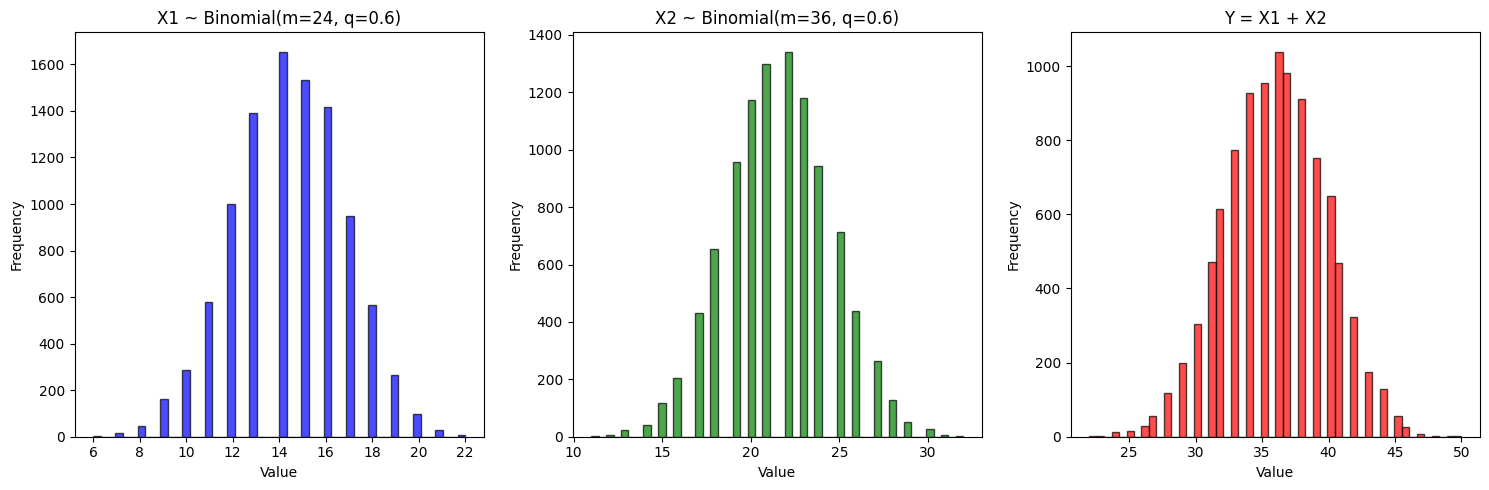

k values with more than 100 observations: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44]
Linear regression results: slope = -1.6321, intercept = 97.1782
a = -1.6321, b = 97.1782
q = 0.62  , m = 59


In [ ]:
# b
np.random.seed(1)
n_sim = 10000
X1_b = np.random.binomial(n=24, p=0.6, size=n_sim)
X2_b = np.random.binomial(n=36, p=0.6, size=n_sim)
Y_b = X1_b + X2_b

# Plot histograms
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(X1_b, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title('X1 ~ Binomial(m=24, q=0.6)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(X2_b, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.title('X2 ~ Binomial(m=36, q=0.6)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(Y_b, bins=50, alpha=0.7, color='red', edgecolor='black')
plt.title('Y = X1 + X2')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Create frequency table and find k's with more than 100 observations
freq_table_b = pd.Series(Y_b).value_counts().sort_index()
k_more_than_100_b = freq_table_b[freq_table_b > 100].index

print("k values with more than 100 observations:", k_more_than_100_b.tolist())

# Prepare data for linear regression
k_values_b = []
ratio_values_b = []

for k in k_more_than_100_b:
    if k-1 in freq_table_b.index and k > 0:
        n_k = freq_table_b[k]
        n_k_minus_1 = freq_table_b[k-1]
        ratio = k * n_k / n_k_minus_1
        k_values_b.append(k)
        ratio_values_b.append(ratio)

# Perform linear regression
if len(k_values_b) > 1:
    slope_b, intercept_b, r_value_b, p_value_b, std_err_b = stats.linregress(k_values_b, ratio_values_b)
    print(f"Linear regression results: slope = {slope_b:.4f}, intercept = {intercept_b:.4f}")
    print(f"a = {slope_b:.4f}, b = {intercept_b:.4f}")
    print(f"q = 0.62  , m = 59")

# In the regression, we know that k(n_k/n_k-1)=b0 + b1k, for (a,b,0), we divide k on both side of the formula. We can get (n_k/n_k-1)=b0/k + b1. So b1=a, b0=b
# we can know that a = -1.6321, b = 97.1782. It's a binomial distribution.
# we can know that q = 0.62  , m = 59.

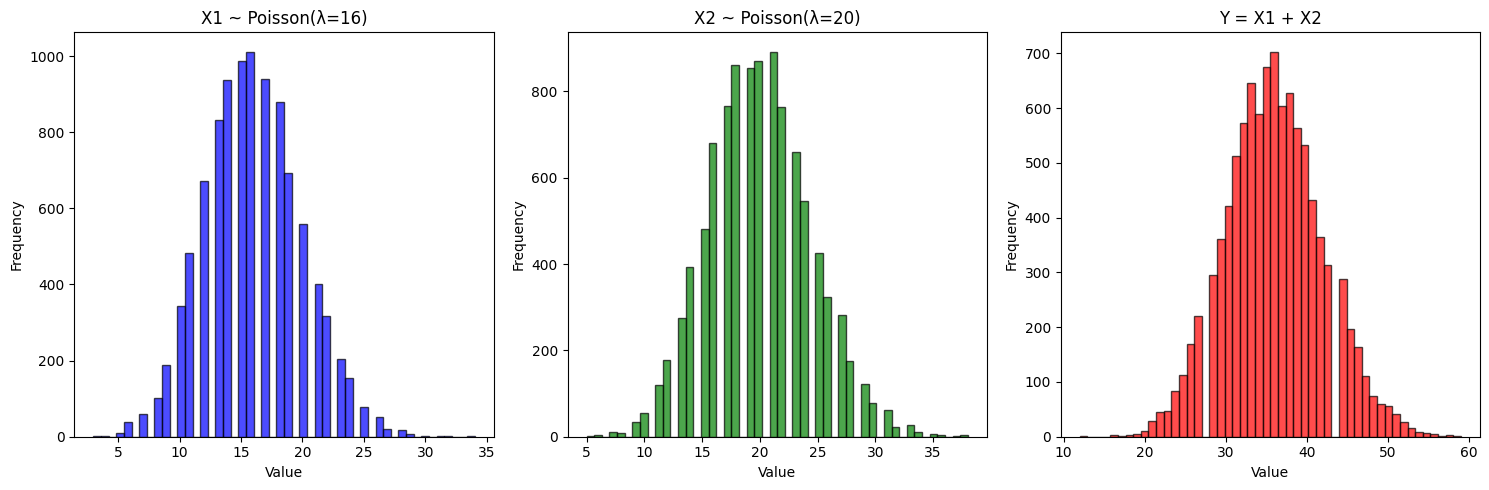

k values with more than 100 observations: [25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
Linear regression results: slope = -0.0443, intercept = 37.4965
a = -0.0443, b = 37.4965
lamda = 37.4965 


In [ ]:
# c
np.random.seed(1)
n_sim = 10000
X1_c = np.random.poisson(lam=16, size=n_sim)
X2_c = np.random.poisson(lam=20, size=n_sim)
Y_c = X1_c + X2_c

# Plot histograms
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(X1_c, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title('X1 ~ Poisson(λ=16)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(X2_c, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.title('X2 ~ Poisson(λ=20)')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(Y_c, bins=50, alpha=0.7, color='red', edgecolor='black')
plt.title('Y = X1 + X2')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Create frequency table and find k's with more than 100 observations
freq_table_c = pd.Series(Y_c).value_counts().sort_index()
k_more_than_100_c = freq_table_c[freq_table_c > 100].index

print("k values with more than 100 observations:", k_more_than_100_c.tolist())

# Prepare data for linear regression
k_values_c = []
ratio_values_c = []

for k in k_more_than_100_c:
    if k-1 in freq_table_c.index and k > 0:
        n_k = freq_table_c[k]
        n_k_minus_1 = freq_table_c[k-1]
        ratio = k * n_k / n_k_minus_1
        k_values_c.append(k)
        ratio_values_c.append(ratio)

# Perform linear regression
if len(k_values_c) > 1:
    slope_c, intercept_c, r_value_c, p_value_c, std_err_c = stats.linregress(k_values_c, ratio_values_c)
    print(f"Linear regression results: slope = {slope_c:.4f}, intercept = {intercept_c:.4f}")
    print(f"a = {slope_c:.4f}, b = {intercept_c:.4f}")
    print(f"lamda = 37.4965 ")

# In the regression, we know that k(n_k/n_k-1)=b0 + b1k, for (a,b,0), we divide k on both side of the formula. We can get (n_k/n_k-1)=b0/k + b1. So b1=a, b0=b
# we can know that a = -0.0443, b = 37.4965. We can see that a is about 0. It's a poisson distribution.
# we can know that lamda = 37.4965.

## Part 2 Compound Distributions

In this part, you will create a collective risk model with N being the number of claims and 𝑋𝑋𝑖𝑖 being the
amount of loss in one year.

Simulate 10,000 draws from 𝑁 and 𝑋𝑖, then compute the sum 𝑆 = 𝑋1 + 𝑋2 + ⋯ + 𝑋𝑁.

Compute 𝐸[𝑆], 𝑉[𝑆], and compare to theoretical values using the law of total expectation.

a. 𝑁 = Poi(𝜆 = 25),𝑋𝑖 = Exp(𝜃 = 100)
b. 𝑁 = Poi(𝜆 = 100),𝑋𝑖 = LogNormal(𝜇 = 1, 𝜎 = 2)
c. 𝑁 = Bin(𝑚 = 36, 𝑞 = 0.6), 𝑋𝑖 = Gamma(𝛼 = 100, 𝜃 = 2)

Empirical Results:
E[S] = 2494.54
Var[S] = 488134.80

Theoretical Results:
E[S] = E[N] * E[X] = 25 * 100 = 2500.00
Var[S] = E[N]*Var[X] + Var[N]*(E[X])^2 = 25*10000 + 25*10000 = 500000.00


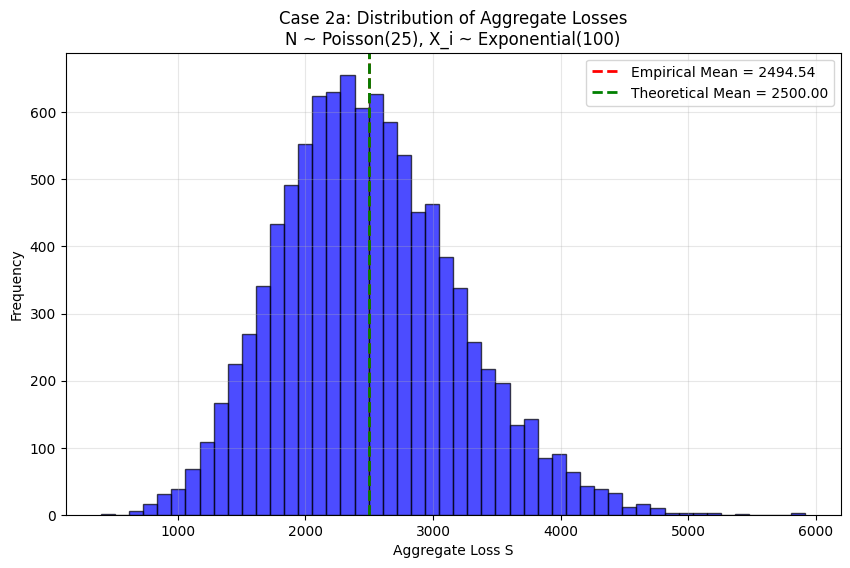

In [ ]:
# a
np.random.seed(1)
num_simulations = 10000

lambda_n = 25
theta_x = 100

N_a = poisson.rvs(lambda_n, size=num_simulations)
S_a = np.zeros(num_simulations)

for i in range(num_simulations):
    if N_a[i] > 0:
        losses = expon.rvs(scale=theta_x, size=N_a[i])
        S_a[i] = np.sum(losses)

# Calculate empirical moments
empirical_mean_a = np.mean(S_a)
empirical_var_a = np.var(S_a)

# Calculate theoretical moments using compound distribution formulas
# E[S] = E[N] * E[X]
theoretical_mean_a = lambda_n * theta_x
# Var[S] = E[N] * Var[X] + Var[N] * (E[X])^2
theoretical_var_a = lambda_n * (theta_x ** 2) + lambda_n * (theta_x ** 2)

print(f"Empirical Results:")
print(f"E[S] = {empirical_mean_a:.2f}")
print(f"Var[S] = {empirical_var_a:.2f}")

print(f"\nTheoretical Results:")
print(f"E[S] = E[N] * E[X] = {lambda_n} * {theta_x} = {theoretical_mean_a:.2f}")
print(f"Var[S] = E[N]*Var[X] + Var[N]*(E[X])^2 = {lambda_n}*{theta_x**2} + {lambda_n}*{theta_x**2} = {theoretical_var_a:.2f}")

# Plot histogram of aggregate losses
plt.figure(figsize=(10, 6))
plt.hist(S_a, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(empirical_mean_a, color='red', linestyle='--', linewidth=2, label=f'Empirical Mean = {empirical_mean_a:.2f}')
plt.axvline(theoretical_mean_a, color='green', linestyle='--', linewidth=2, label=f'Theoretical Mean = {theoretical_mean_a:.2f}')
plt.xlabel('Aggregate Loss S')
plt.ylabel('Frequency')
plt.title('Case 2a: Distribution of Aggregate Losses\nN ~ Poisson(25), X_i ~ Exponential(100)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Individual Loss Distribution (LogNormal):
E[X] = exp(μ + σ²/2) = exp(1 + 4/2) = 20.09
Var[X] = [exp(σ²) - 1] * exp(2μ + σ²) = [exp(4) - 1] * exp(6) = 21623.04

Empirical Results:
E[S] = 1992.66
Var[S] = 1697927.54

Theoretical Results:
E[S] = E[N] * E[X] = 100 * 20.09 = 2008.55
Var[S] = E[N]*Var[X] + Var[N]*(E[X])^2 = 100*21623.04 + 100*403.43 = 2202646.58


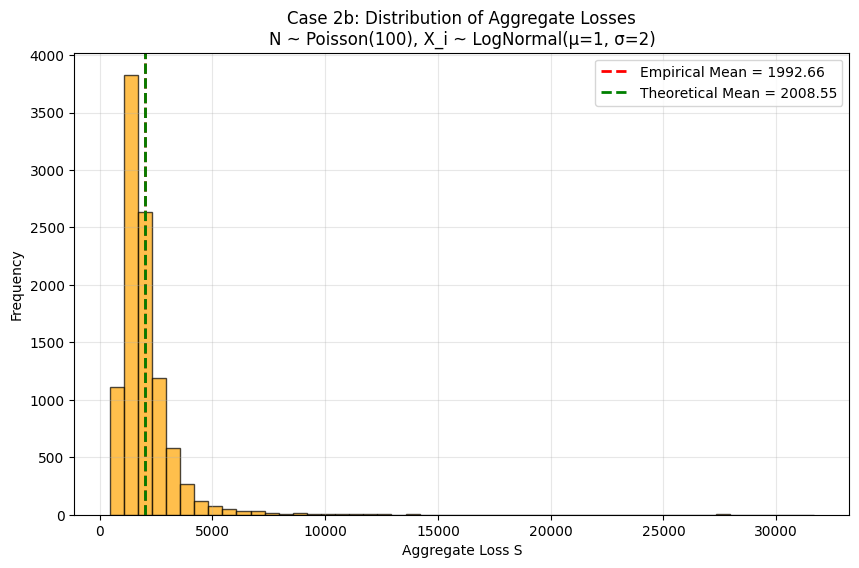

In [ ]:
# b
np.random.seed(1)
num_simulations = 10000

lambda_n = 100
mu_x = 1
sigma_x = 2

N_b = poisson.rvs(lambda_n, size=num_simulations)
S_b = np.zeros(num_simulations)

for i in range(num_simulations):
    if N_b[i] > 0:
        losses = lognorm.rvs(s=sigma_x, scale=np.exp(mu_x), size=N_b[i])
        S_b[i] = np.sum(losses)

empirical_mean_b = np.mean(S_b)
empirical_var_b = np.var(S_b)

E_X_b = np.exp(mu_x + (sigma_x ** 2) / 2)
Var_X_b = (np.exp(sigma_x ** 2) - 1) * np.exp(2 * mu_x + sigma_x ** 2)

# Theoretical moments for compound distribution
theoretical_mean_b = lambda_n * E_X_b
theoretical_var_b = lambda_n * Var_X_b + lambda_n * (E_X_b ** 2)

print(f"Individual Loss Distribution (LogNormal):")
print(f"E[X] = exp(μ + σ²/2) = exp({mu_x} + {sigma_x**2}/2) = {E_X_b:.2f}")
print(f"Var[X] = [exp(σ²) - 1] * exp(2μ + σ²) = [exp({sigma_x**2}) - 1] * exp({2*mu_x + sigma_x**2}) = {Var_X_b:.2f}")

print(f"\nEmpirical Results:")
print(f"E[S] = {empirical_mean_b:.2f}")
print(f"Var[S] = {empirical_var_b:.2f}")

print(f"\nTheoretical Results:")
print(f"E[S] = E[N] * E[X] = {lambda_n} * {E_X_b:.2f} = {theoretical_mean_b:.2f}")
print(f"Var[S] = E[N]*Var[X] + Var[N]*(E[X])^2 = {lambda_n}*{Var_X_b:.2f} + {lambda_n}*{E_X_b**2:.2f} = {theoretical_var_b:.2f}")

# Plot histogram of aggregate losses
plt.figure(figsize=(10, 6))
plt.hist(S_b, bins=50, alpha=0.7, color='orange', edgecolor='black')
plt.axvline(empirical_mean_b, color='red', linestyle='--', linewidth=2, label=f'Empirical Mean = {empirical_mean_b:.2f}')
plt.axvline(theoretical_mean_b, color='green', linestyle='--', linewidth=2, label=f'Theoretical Mean = {theoretical_mean_b:.2f}')
plt.xlabel('Aggregate Loss S')
plt.ylabel('Frequency')
plt.title('Case 2b: Distribution of Aggregate Losses\nN ~ Poisson(100), X_i ~ LogNormal(μ=1, σ=2)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Claim Count Distribution (Binomial):
E[N] = m*q = 36 * 0.6 = 21.60
Var[N] = m*q*(1-q) = 36 * 0.6 * 0.4 = 8.64

Individual Loss Distribution (Gamma):
E[X] = α*θ = 100 * 2 = 200.00
Var[X] = α*θ² = 100 * 4 = 400.00

Empirical Results:
E[S] = 4324.36
Var[S] = 351749.97

Theoretical Results:
E[S] = E[N] * E[X] = 21.60 * 200.00 = 4320.00
Var[S] = E[N]*Var[X] + Var[N]*(E[X])^2 = 21.60*400.00 + 8.64*40000.00 = 354240.00


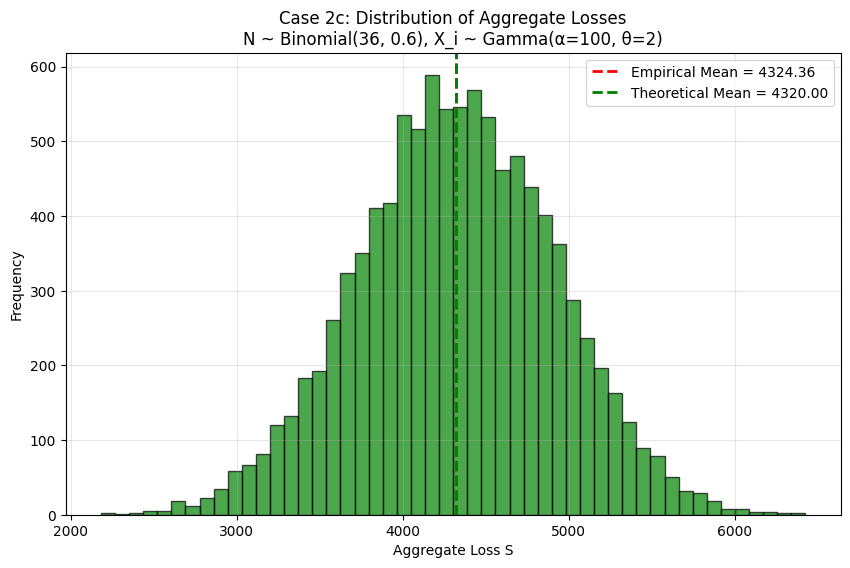

In [ ]:
# c
np.random.seed(1)
num_simulations = 10000

m_n = 36
q_n = 0.6
alpha_x = 100
theta_x = 2

N_c = binom.rvs(n=m_n, p=q_n, size=num_simulations)
S_c = np.zeros(num_simulations)

for i in range(num_simulations):
    if N_c[i] > 0:
        losses = gamma.rvs(a=alpha_x, scale=theta_x, size=N_c[i])
        S_c[i] = np.sum(losses)

empirical_mean_c = np.mean(S_c)
empirical_var_c = np.var(S_c)

E_N_c = m_n * q_n
Var_N_c = m_n * q_n * (1 - q_n)

E_X_c = alpha_x * theta_x
Var_X_c = alpha_x * (theta_x ** 2)

# Theoretical moments for compound distribution
theoretical_mean_c = E_N_c * E_X_c
theoretical_var_c = E_N_c * Var_X_c + Var_N_c * (E_X_c ** 2)

print(f"Claim Count Distribution (Binomial):")
print(f"E[N] = m*q = {m_n} * {q_n} = {E_N_c:.2f}")
print(f"Var[N] = m*q*(1-q) = {m_n} * {q_n} * {1-q_n} = {Var_N_c:.2f}")

print(f"\nIndividual Loss Distribution (Gamma):")
print(f"E[X] = α*θ = {alpha_x} * {theta_x} = {E_X_c:.2f}")
print(f"Var[X] = α*θ² = {alpha_x} * {theta_x**2} = {Var_X_c:.2f}")

print(f"\nEmpirical Results:")
print(f"E[S] = {empirical_mean_c:.2f}")
print(f"Var[S] = {empirical_var_c:.2f}")

print(f"\nTheoretical Results:")
print(f"E[S] = E[N] * E[X] = {E_N_c:.2f} * {E_X_c:.2f} = {theoretical_mean_c:.2f}")
print(f"Var[S] = E[N]*Var[X] + Var[N]*(E[X])^2 = {E_N_c:.2f}*{Var_X_c:.2f} + {Var_N_c:.2f}*{E_X_c**2:.2f} = {theoretical_var_c:.2f}")

# Plot histogram of aggregate losses
plt.figure(figsize=(10, 6))
plt.hist(S_c, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.axvline(empirical_mean_c, color='red', linestyle='--', linewidth=2, label=f'Empirical Mean = {empirical_mean_c:.2f}')
plt.axvline(theoretical_mean_c, color='green', linestyle='--', linewidth=2, label=f'Theoretical Mean = {theoretical_mean_c:.2f}')
plt.xlabel('Aggregate Loss S')
plt.ylabel('Frequency')
plt.title('Case 2c: Distribution of Aggregate Losses\nN ~ Binomial(36, 0.6), X_i ~ Gamma(α=100, θ=2)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Part 3 Credibility Theory

In this part, you will simulate observations of the compound distributions in Part 2 to find how often the
aggregate sum is close to the theoretical sum.

Simulate 100 years of aggregate losses and calculate the average. Determine if the average is
within 𝑟% of the theoretical mean.

Repeat 100 times and determine the empirical probability of being within 𝑟% of the mean.

Use limited fluctuation theory to determine 𝑝𝑝 and compare to the empirical probability.

a. 𝑟 = 10%

b. 𝑟 = 5%

c. 𝑟 = 20%

r = 10%:
  Tolerance: ±250.00
  Empirical Probability: 1.000
  Theoretical Probability: 1.000
  Difference: 0.000
  Z-Score: 3.536
r = 5%:
  Tolerance: ±125.00
  Empirical Probability: 0.930
  Theoretical Probability: 0.923
  Difference: 0.007
  Z-Score: 1.768
r = 20%:
  Tolerance: ±500.00
  Empirical Probability: 1.000
  Theoretical Probability: 1.000
  Difference: 0.000
  Z-Score: 7.071

r = 10%:
  Tolerance: ±200.86
  Empirical Probability: 0.930
  Theoretical Probability: 0.824
  Difference: 0.106
  Z-Score: 1.353
r = 5%:
  Tolerance: ±100.43
  Empirical Probability: 0.660
  Theoretical Probability: 0.501
  Difference: 0.159
  Z-Score: 0.677
r = 20%:
  Tolerance: ±401.71
  Empirical Probability: 0.990
  Theoretical Probability: 0.993
  Difference: -0.003
  Z-Score: 2.707

r = 10%:
  Tolerance: ±432.00
  Empirical Probability: 1.000
  Theoretical Probability: 1.000
  Difference: 0.000
  Z-Score: 7.258
r = 5%:
  Tolerance: ±216.00
  Empirical Probability: 1.000
  Theoretical Probabil

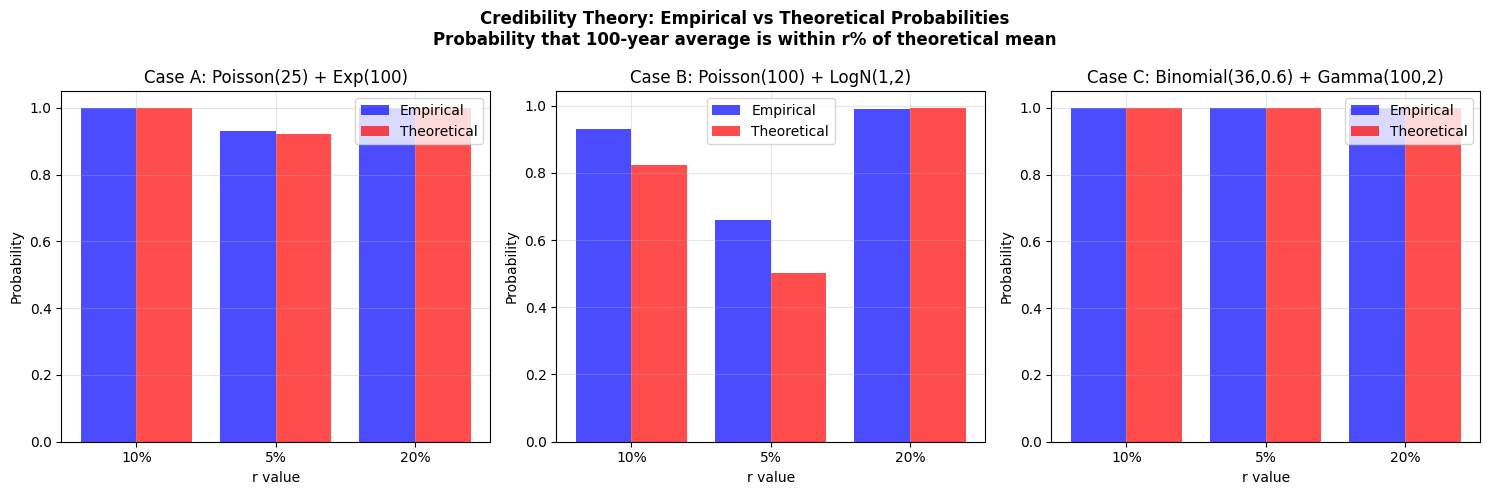

In [ ]:
np.random.seed(1)

# Case a: N ~ Poisson(25), X_i ~ Exponential(100)
lambda_a = 25
theta_a = 100
theoretical_mean_a = lambda_a * theta_a  # 2500

# Case b: N ~ Poisson(100), X_i ~ LogNormal(1,2)
lambda_b = 100
mu_b = 1
sigma_b = 2
E_X_b = np.exp(mu_b + (sigma_b ** 2) / 2)  # exp(1 + 2) = exp(3)
theoretical_mean_b = lambda_b * E_X_b  # 100 * exp(3)

# Case c: N ~ Binomial(36, 0.6), X_i ~ Gamma(100, 2)
m_c = 36
q_c = 0.6
alpha_c = 100
theta_c = 2
E_N_c = m_c * q_c  # 21.6
E_X_c = alpha_c * theta_c  # 200
theoretical_mean_c = E_N_c * E_X_c  # 4320

# r values to test
r_values = [0.10, 0.05, 0.20]  # 10%, 5%, 20%
num_years = 100
num_experiments = 100

# Store all results
all_results = []

# CASE A

case_a_results = []

for r in r_values:
    tolerance = r * theoretical_mean_a
    within_tolerance_count = 0

    # Run 100 experiments
    for exp in range(num_experiments):
        # Simulate 100 years of aggregate losses
        annual_losses = []
        for year in range(num_years):
            # Simulate number of claims
            N = poisson.rvs(lambda_a)
            if N > 0:
                # Simulate losses
                losses = expon.rvs(scale=theta_a, size=N)
                annual_loss = np.sum(losses)
            else:
                annual_loss = 0
            annual_losses.append(annual_loss)

        # Calculate sample mean
        sample_mean = np.mean(annual_losses)

        # Check if within tolerance
        if abs(sample_mean - theoretical_mean_a) <= tolerance:
            within_tolerance_count += 1

    empirical_prob = within_tolerance_count / num_experiments

    # Theoretical probability using limited fluctuation theory
    # Variance from Part 2: Var[S] = lambda * theta^2 + lambda * theta^2 = 2 * lambda * theta^2
    variance_a = 2 * lambda_a * (theta_a ** 2)
    standard_error = np.sqrt(variance_a / num_years)
    z_score = (r * theoretical_mean_a) / standard_error
    theoretical_prob = 2 * norm.cdf(z_score) - 1

    result = {
        'Case': 'a',
        'r': f'{r*100:.0f}%',
        'Theoretical_Mean': theoretical_mean_a,
        'Tolerance': tolerance,
        'Empirical_Probability': empirical_prob,
        'Theoretical_Probability': theoretical_prob,
        'Difference': empirical_prob - theoretical_prob,
        'Z_Score': z_score
    }
    case_a_results.append(result)
    all_results.append(result)

    print(f"r = {r*100:.0f}%:")
    print(f"  Tolerance: ±{tolerance:.2f}")
    print(f"  Empirical Probability: {empirical_prob:.3f}")
    print(f"  Theoretical Probability: {theoretical_prob:.3f}")
    print(f"  Difference: {empirical_prob - theoretical_prob:.3f}")
    print(f"  Z-Score: {z_score:.3f}")

print()

# CASE B
case_b_results = []

for r in r_values:
    tolerance = r * theoretical_mean_b
    within_tolerance_count = 0

    # Run 100 experiments
    for exp in range(num_experiments):
        # Simulate 100 years of aggregate losses
        annual_losses = []
        for year in range(num_years):
            # Simulate number of claims
            N = poisson.rvs(lambda_b)
            if N > 0:
                # Simulate lognormal losses
                losses = lognorm.rvs(s=sigma_b, scale=np.exp(mu_b), size=N)
                annual_loss = np.sum(losses)
            else:
                annual_loss = 0
            annual_losses.append(annual_loss)

        # Calculate sample mean
        sample_mean = np.mean(annual_losses)

        # Check if within tolerance
        if abs(sample_mean - theoretical_mean_b) <= tolerance:
            within_tolerance_count += 1

    empirical_prob = within_tolerance_count / num_experiments

    # Theoretical probability using limited fluctuation theory
    # Variance from Part 2
    E_X_b = np.exp(mu_b + (sigma_b ** 2) / 2)
    Var_X_b = (np.exp(sigma_b ** 2) - 1) * np.exp(2 * mu_b + sigma_b ** 2)
    variance_b = lambda_b * Var_X_b + lambda_b * (E_X_b ** 2)
    standard_error = np.sqrt(variance_b / num_years)
    z_score = (r * theoretical_mean_b) / standard_error
    theoretical_prob = 2 * norm.cdf(z_score) - 1

    result = {
        'Case': 'b',
        'r': f'{r*100:.0f}%',
        'Theoretical_Mean': theoretical_mean_b,
        'Tolerance': tolerance,
        'Empirical_Probability': empirical_prob,
        'Theoretical_Probability': theoretical_prob,
        'Difference': empirical_prob - theoretical_prob,
        'Z_Score': z_score
    }
    case_b_results.append(result)
    all_results.append(result)

    print(f"r = {r*100:.0f}%:")
    print(f"  Tolerance: ±{tolerance:.2f}")
    print(f"  Empirical Probability: {empirical_prob:.3f}")
    print(f"  Theoretical Probability: {theoretical_prob:.3f}")
    print(f"  Difference: {empirical_prob - theoretical_prob:.3f}")
    print(f"  Z-Score: {z_score:.3f}")

print()

# CASE C
case_c_results = []

for r in r_values:
    tolerance = r * theoretical_mean_c
    within_tolerance_count = 0

    # Run 100 experiments
    for exp in range(num_experiments):
        # Simulate 100 years of aggregate losses
        annual_losses = []
        for year in range(num_years):
            # Simulate number of claims
            N = binom.rvs(n=m_c, p=q_c)
            if N > 0:
                # Simulate gamma losses
                losses = gamma.rvs(a=alpha_c, scale=theta_c, size=N)
                annual_loss = np.sum(losses)
            else:
                annual_loss = 0
            annual_losses.append(annual_loss)

        # Calculate sample mean
        sample_mean = np.mean(annual_losses)

        # Check if within tolerance
        if abs(sample_mean - theoretical_mean_c) <= tolerance:
            within_tolerance_count += 1

    empirical_prob = within_tolerance_count / num_experiments

    # Theoretical probability using limited fluctuation theory
    # Variance from Part 2
    E_N_c = m_c * q_c
    Var_N_c = m_c * q_c * (1 - q_c)
    E_X_c = alpha_c * theta_c
    Var_X_c = alpha_c * (theta_c ** 2)
    variance_c = E_N_c * Var_X_c + Var_N_c * (E_X_c ** 2)
    standard_error = np.sqrt(variance_c / num_years)
    z_score = (r * theoretical_mean_c) / standard_error
    theoretical_prob = 2 * norm.cdf(z_score) - 1

    result = {
        'Case': 'c',
        'r': f'{r*100:.0f}%',
        'Theoretical_Mean': theoretical_mean_c,
        'Tolerance': tolerance,
        'Empirical_Probability': empirical_prob,
        'Theoretical_Probability': theoretical_prob,
        'Difference': empirical_prob - theoretical_prob,
        'Z_Score': z_score
    }
    case_c_results.append(result)
    all_results.append(result)

    print(f"r = {r*100:.0f}%:")
    print(f"  Tolerance: ±{tolerance:.2f}")
    print(f"  Empirical Probability: {empirical_prob:.3f}")
    print(f"  Theoretical Probability: {theoretical_prob:.3f}")
    print(f"  Difference: {empirical_prob - theoretical_prob:.3f}")
    print(f"  Z-Score: {z_score:.3f}")

print()

# Create summary table
print("=== SUMMARY TABLE ===")
results_df = pd.DataFrame(all_results)
summary_table = results_df[['Case', 'r', 'Theoretical_Mean', 'Tolerance',
                           'Empirical_Probability', 'Theoretical_Probability', 'Difference']]
print(summary_table.round(4))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Case A plot
case_a_df = pd.DataFrame(case_a_results)
x_pos = np.arange(len(r_values))
axes[0].bar(x_pos - 0.2, case_a_df['Empirical_Probability'], width=0.4,
           label='Empirical', alpha=0.7, color='blue')
axes[0].bar(x_pos + 0.2, case_a_df['Theoretical_Probability'], width=0.4,
           label='Theoretical', alpha=0.7, color='red')
axes[0].set_title('Case A: Poisson(25) + Exp(100)')
axes[0].set_xlabel('r value')
axes[0].set_ylabel('Probability')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['10%', '5%', '20%'])
axes[0].legend()
axes[0].grid(alpha=0.3)

# Case B plot
case_b_df = pd.DataFrame(case_b_results)
axes[1].bar(x_pos - 0.2, case_b_df['Empirical_Probability'], width=0.4,
           label='Empirical', alpha=0.7, color='blue')
axes[1].bar(x_pos + 0.2, case_b_df['Theoretical_Probability'], width=0.4,
           label='Theoretical', alpha=0.7, color='red')
axes[1].set_title('Case B: Poisson(100) + LogN(1,2)')
axes[1].set_xlabel('r value')
axes[1].set_ylabel('Probability')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['10%', '5%', '20%'])
axes[1].legend()
axes[1].grid(alpha=0.3)

# Case C plot
case_c_df = pd.DataFrame(case_c_results)
axes[2].bar(x_pos - 0.2, case_c_df['Empirical_Probability'], width=0.4,
           label='Empirical', alpha=0.7, color='blue')
axes[2].bar(x_pos + 0.2, case_c_df['Theoretical_Probability'], width=0.4,
           label='Theoretical', alpha=0.7, color='red')
axes[2].set_title('Case C: Binomial(36,0.6) + Gamma(100,2)')
axes[2].set_xlabel('r value')
axes[2].set_ylabel('Probability')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(['10%', '5%', '20%'])
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Credibility Theory: Empirical vs Theoretical Probabilities\n'
             'Probability that 100-year average is within r% of theoretical mean',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
